# Latent-I2SB testbench

Loads the two trained latent-I2SB regressors and evaluates them:

1. **latent-bridge** run (`bridge_domain="latent"`) -> reverse bridge in the M-channel latent
   (`latent_i2sb_sample`), one decode at the end.
2. **image-bridge** run (`bridge_domain="image"`) -> reverse bridge in the T1ce image domain
   (`latent_i2sb_sample_imgdomain`), joint dict re-encodes each step.
3. **single-pass** validation for both, at a sweep of bridge steps `t` -- one network forward at a
   fixed step (exactly the training `single_pass`), decoded and scored vs GT.

Run on the HPC node (torch 2.x, BraTS data, trained dict + R checkpoints).

In [1]:
import os, sys, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# ---- the two trained runs (SAVED config.json each train.py writes into its save_dir) ----
LATENT_CFG = "trained_nets/brats/Latent_I2SB_T1ce_LatentInferenceLatentBridge/config.json"  # bridge_domain="latent"
IMAGE_CFG  = "trained_nets/brats/Latent_I2SB_T1ce_LatentInferenceImageBridge/config.json"    # bridge_domain="image"

# ---- knobs ----
SPLIT   = "val"
NFE     = 100                              # full-recon reverse steps (must be < n_points)
T_STEPS = [999, 990, 950, 900, 800, 500]   # single-pass step indices (n_points = 1000)
SEED    = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
npy = lambda t: t.detach().cpu().numpy()
print("repo:", REPO_ROOT, "| device:", device)

repo: /scratch/ee2178/ImMAP | device: cuda


## 1. Load both trained runs (R + frozen dicts + schedule)

In [13]:
from models import build_model
from training.common import apply_loss_mask
from training.metrics import compute_metrics
from training.latent_i2sb import _load_frozen_dict, _latent_forward, _assert_latent_shapes
from sb.base import build_schedule, n_steps
from sb.latent_i2sb import latent_i2sb_sample, latent_i2sb_sample_imgdomain

def load_run(config_path):
    """Build R from the saved config, load its net.ckpt, load the two frozen dicts, build the
    bridge schedule. Returns a dict describing the run."""
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"{config_path} not found -- train this run first (train.py).")
    with open(config_path) as f:
        cfg = json.load(f)
    ic, dc = cfg["i2sb"], cfg["dicts"]
    sd = os.path.dirname(config_path)

    R = build_model(cfg).to(device)
    ckpt = torch.load(os.path.join(sd, "net.ckpt"), map_location=device, weights_only=False)
    R.load_state_dict(ckpt["model_state_dict"]); R.eval()
    if getattr(R, "attn_backend", None) == "flex":
        R.compile_flex()                                   # parity with train.py main()

    D_joint = _load_frozen_dict(dc["joint_dict_config"], device, backend=dc.get("dict_backend"))
    D_t1ce  = _load_frozen_dict(dc["t1ce_dict_config"],  device, backend=dc.get("dict_backend"))
    bridge  = build_schedule(kind=ic.get("kind", "brownian"), tau=ic["tau"],
                             n_points=ic["n_points"], beta_max=ic.get("beta_max", 0.3), device=device)
    
    return dict(cfg=cfg, R=R, D_joint=D_joint, D_t1ce=D_t1ce, bridge=bridge, ckpt_step=ckpt.get("step"),
                bridge_domain=ic["bridge_domain"], M=D_joint.M, decode_dc=ic.get("decode_dc", "x1_mean"),
                deterministic=ic.get("deterministic", False), posterior=ic.get("posterior", "ddpm"),
                n_points=n_steps(bridge), ok=True)

lat = load_run(LATENT_CFG)
img = load_run(IMAGE_CFG)
for tag, run in [("latent-bridge", lat), ("image-bridge", img)]:
    print(f"{tag:12s}: bridge_domain={run['bridge_domain']:7s} R.C={run['R'].C} M={run['M']} "
          f"tau={run['cfg']['i2sb']['tau']} n_points={run['n_points']} step={run['ckpt_step']}")

W matrix returns L = 1044.344970703125
W matrix returns L = 553.6951904296875
W matrix returns L = 518.931396484375
W matrix returns L = 1037.816162109375
W matrix returns L = 521.4881591796875
W matrix returns L = 527.3980712890625
latent-bridge: bridge_domain=latent  R.C=128 M=64 tau=0.024 n_points=1000 step=269350
image-bridge: bridge_domain=image   R.C=64 M=64 tau=0.19 n_points=1000 step=114550


## 2. Val batch + shape sanity\n\nBoth runs share the same data/`cond_idx`, so one loader serves both. `_assert_latent_shapes` checks each run's `D_joint.C` / `R.C` against its `bridge_domain` (latent -> cond-only dict + `R.C=2M`; image -> 4-ch dict + `R.C=M`).

In [18]:
import datasets                                   # registers loaders
from datasets.registry import build_loader

val_cfg = dict(lat["cfg"]["data"][SPLIT]); val_cfg["num_workers"] = 0
loader = build_loader(val_cfg, shuffle=True, drop_last=False)
x0, x1, cond, mask = next(iter(loader))
x0, x1, cond, mask = x0.to(device), x1.to(device), cond.to(device), mask.to(device)
print("x0", tuple(x0.shape), "| x1", tuple(x1.shape), "| cond", tuple(cond.shape), "| mask", tuple(mask.shape))
assert max(T_STEPS) < lat["n_points"], f"T_STEPS must be < n_points={lat['n_points']}"

# per-run shape check; don't hard-fail so a good run still works if the other is misconfigured
for tag, run in [("latent-bridge", lat), ("image-bridge", img)]:
    try:
        _assert_latent_shapes(run["bridge_domain"], run["D_joint"], run["R"], run["D_t1ce"], loader, 1)
        print(f"[ok]  {tag}: shapes consistent")
    except Exception as e:
        run["ok"] = False
        print(f"[BAD] {tag}: {e}")

x0 (8, 1, 192, 192) | x1 (8, 1, 192, 192) | cond (8, 3, 192, 192) | mask (8, 1, 192, 192)
[ok]  latent-bridge: shapes consistent
[ok]  image-bridge: shapes consistent


## 3. Full recon  (latent-bridge in latent space  vs  image-bridge in image domain)

SB reverse [ddpm]: 100%|██████████| 100/100 [00:00<00:00, 115.64it/s]


latent-bridge recon: 0.9s


SB reverse [ddpm]: 100%|██████████| 100/100 [00:01<00:00, 66.45it/s]


image-bridge recon:  1.5s


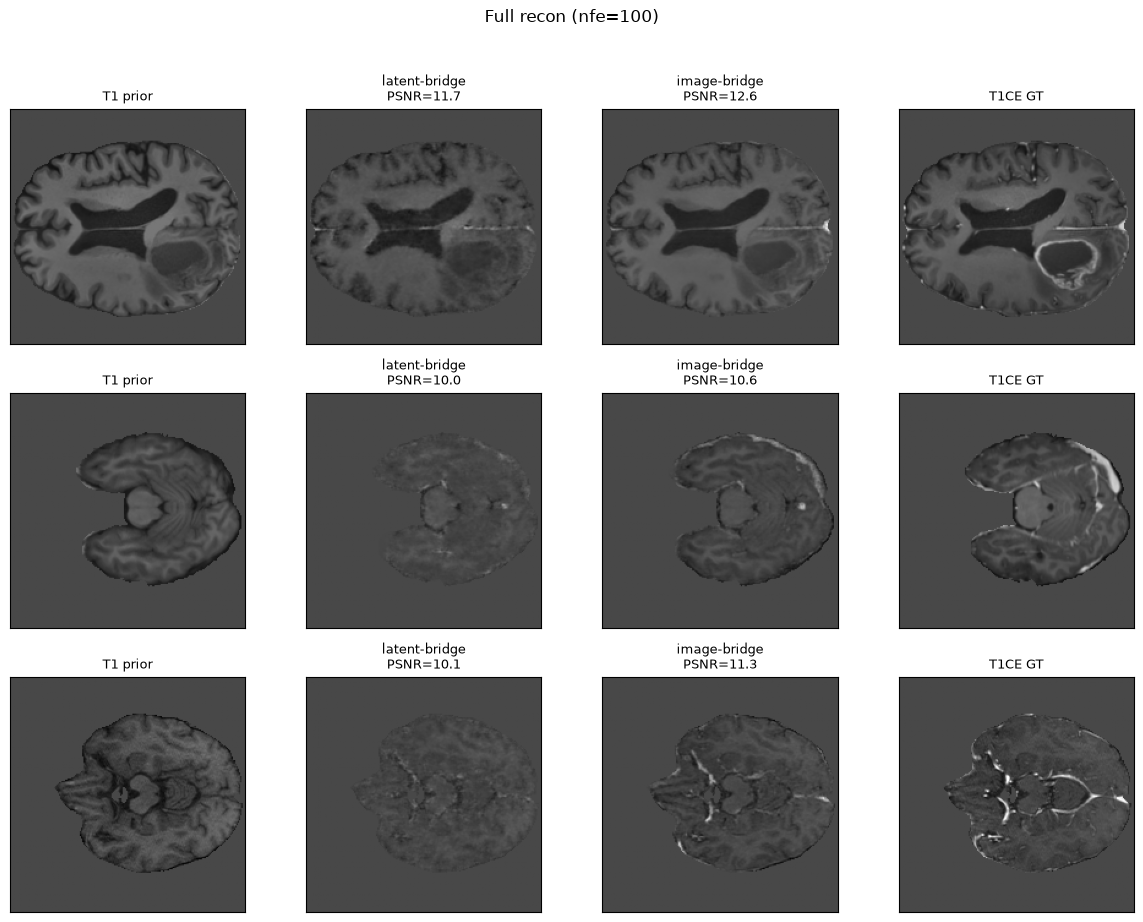

In [19]:
def disp_win(*imgs):
    v = torch.cat([i.flatten() for i in imgs]); lo = float(v.min()); return lo, max(float(v.max()), lo + 1e-8)

recons = {}
if lat["ok"]:
    t0 = time.time()
    recons["latent-bridge"] = latent_i2sb_sample(
        lat["D_joint"], lat["R"], lat["D_t1ce"], x1, cond, lat["bridge"], M=lat["M"], nfe=NFE,
        deterministic=lat["deterministic"], posterior=lat["posterior"], decode_dc=lat["decode_dc"], verbose=True)
    print(f"latent-bridge recon: {time.time()-t0:.1f}s")
if img["ok"]:
    t0 = time.time()
    recons["image-bridge"] = latent_i2sb_sample_imgdomain(
        img["D_joint"], img["R"], img["D_t1ce"], x1, cond, img["bridge"], M=img["M"], nfe=NFE,
        deterministic=img["deterministic"], posterior=img["posterior"], decode_dc=img["decode_dc"], verbose=True)
    print(f"image-bridge recon:  {time.time()-t0:.1f}s")

names = list(recons)
ncol = 2 + len(names)                                    # prior | <recons> | GT
nshow = min(3, x0.shape[0])
lo, hi = disp_win(mask[:nshow] * x1[:nshow], mask[:nshow] * x0[:nshow])
fig, ax = plt.subplots(nshow, ncol, figsize=(3 * ncol, 3 * nshow)); ax = np.atleast_2d(ax)
for i in range(nshow):
    cols = [("T1 prior", x1[i, 0])]
    for nm in names:
        g, r = apply_loss_mask(x0[i:i+1], recons[nm][i:i+1], mask[i:i+1], use_mask=True)
        ps = float(compute_metrics(g, r, psnr_only=True)["psnr"])
        cols.append((f"{nm}\nPSNR={ps:.1f}", (mask[i] * recons[nm][i])[0]))
    cols.append(("T1CE GT", (mask[i] * x0[i])[0]))
    for a, (ttl, im) in zip(ax[i], cols):
        a.imshow(npy(im), cmap="gray", vmin=lo, vmax=hi); a.set_title(ttl, fontsize=9)
        a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"Full recon (nfe={NFE})", y=1.02); plt.tight_layout(); plt.show()

## 4. Single-pass validation across t\n\nOne network forward at each fixed step `t` (= the training `single_pass`): sample the bridge point at `t`, regress, decode, score vs GT. High `t` is near the prior (hardest); `t=500` is mid-bridge.

In [20]:
def single_pass(run, t_step):
    step = torch.full((x0.shape[0],), int(t_step), device=device, dtype=torch.long)
    with torch.no_grad():
        z0, z0_hat, pred_x0, _ = _latent_forward(
            run["bridge_domain"], run["D_joint"], run["R"], run["D_t1ce"],
            x0, x1, cond, run["bridge"], step, run["deterministic"], run["M"], run["decode_dc"])
    return pred_x0, z0, z0_hat

def latent_relerr(z0, z0_hat):
    """Mean per-sample ||z0_hat - z0|| / ||z0|| in the T1ce latent. ~1 means R's latent output is
    ~orthogonal to the true code (the earlier latent-collapse signature); ->0 is a faithful latent."""
    num = (z0_hat - z0).flatten(1).norm(dim=1)
    den = z0.flatten(1).norm(dim=1).clamp_min(1e-8)
    return float((num / den).mean())

runs = [("latent-bridge", lat), ("image-bridge", img)]
preds = {}                                               # (name, t) -> pred for example 0
print(f"{'run':13s} {'t':>5} {'PSNR':>7} {'SSIM':>7} {'NRMSE':>7} {'z-relerr':>9}")
for name, run in runs:
    if not run["ok"]:
        print(f"{name:13s}  -- skipped (shape check failed)"); continue
    torch.manual_seed(SEED)                              # comparable noise draws across runs
    for t in T_STEPS:
        pred, z0, z0_hat = single_pass(run, t)
        g, r = apply_loss_mask(x0, pred, mask, use_mask=True)
        m = compute_metrics(g, r, psnr_only=False)
        preds[(name, t)] = pred[0:1]
        print(f"{name:13s} {t:5d} {float(m['psnr']):7.2f} {float(m['ssim']):7.3f} "
              f"{float(m['nrmse']):7.4f} {latent_relerr(z0, z0_hat):9.3f}")

run               t    PSNR    SSIM   NRMSE  z-relerr
latent-bridge   999   12.99   0.731  0.0357     0.708
latent-bridge   990   17.54   0.829  0.0220     0.486
latent-bridge   950   21.67   0.901  0.0131     0.342
latent-bridge   900   23.57   0.927  0.0106     0.292
latent-bridge   800   25.51   0.948  0.0081     0.247
latent-bridge   500   28.28   0.971  0.0061     0.190
image-bridge    999   13.01   0.751  0.0363     0.698
image-bridge    990   13.11   0.753  0.0362     0.692
image-bridge    950   14.10   0.768  0.0321     0.635
image-bridge    900   15.11   0.786  0.0238     0.583
image-bridge    800   17.33   0.826  0.0187     0.486
image-bridge    500   21.20   0.887  0.0132     0.354


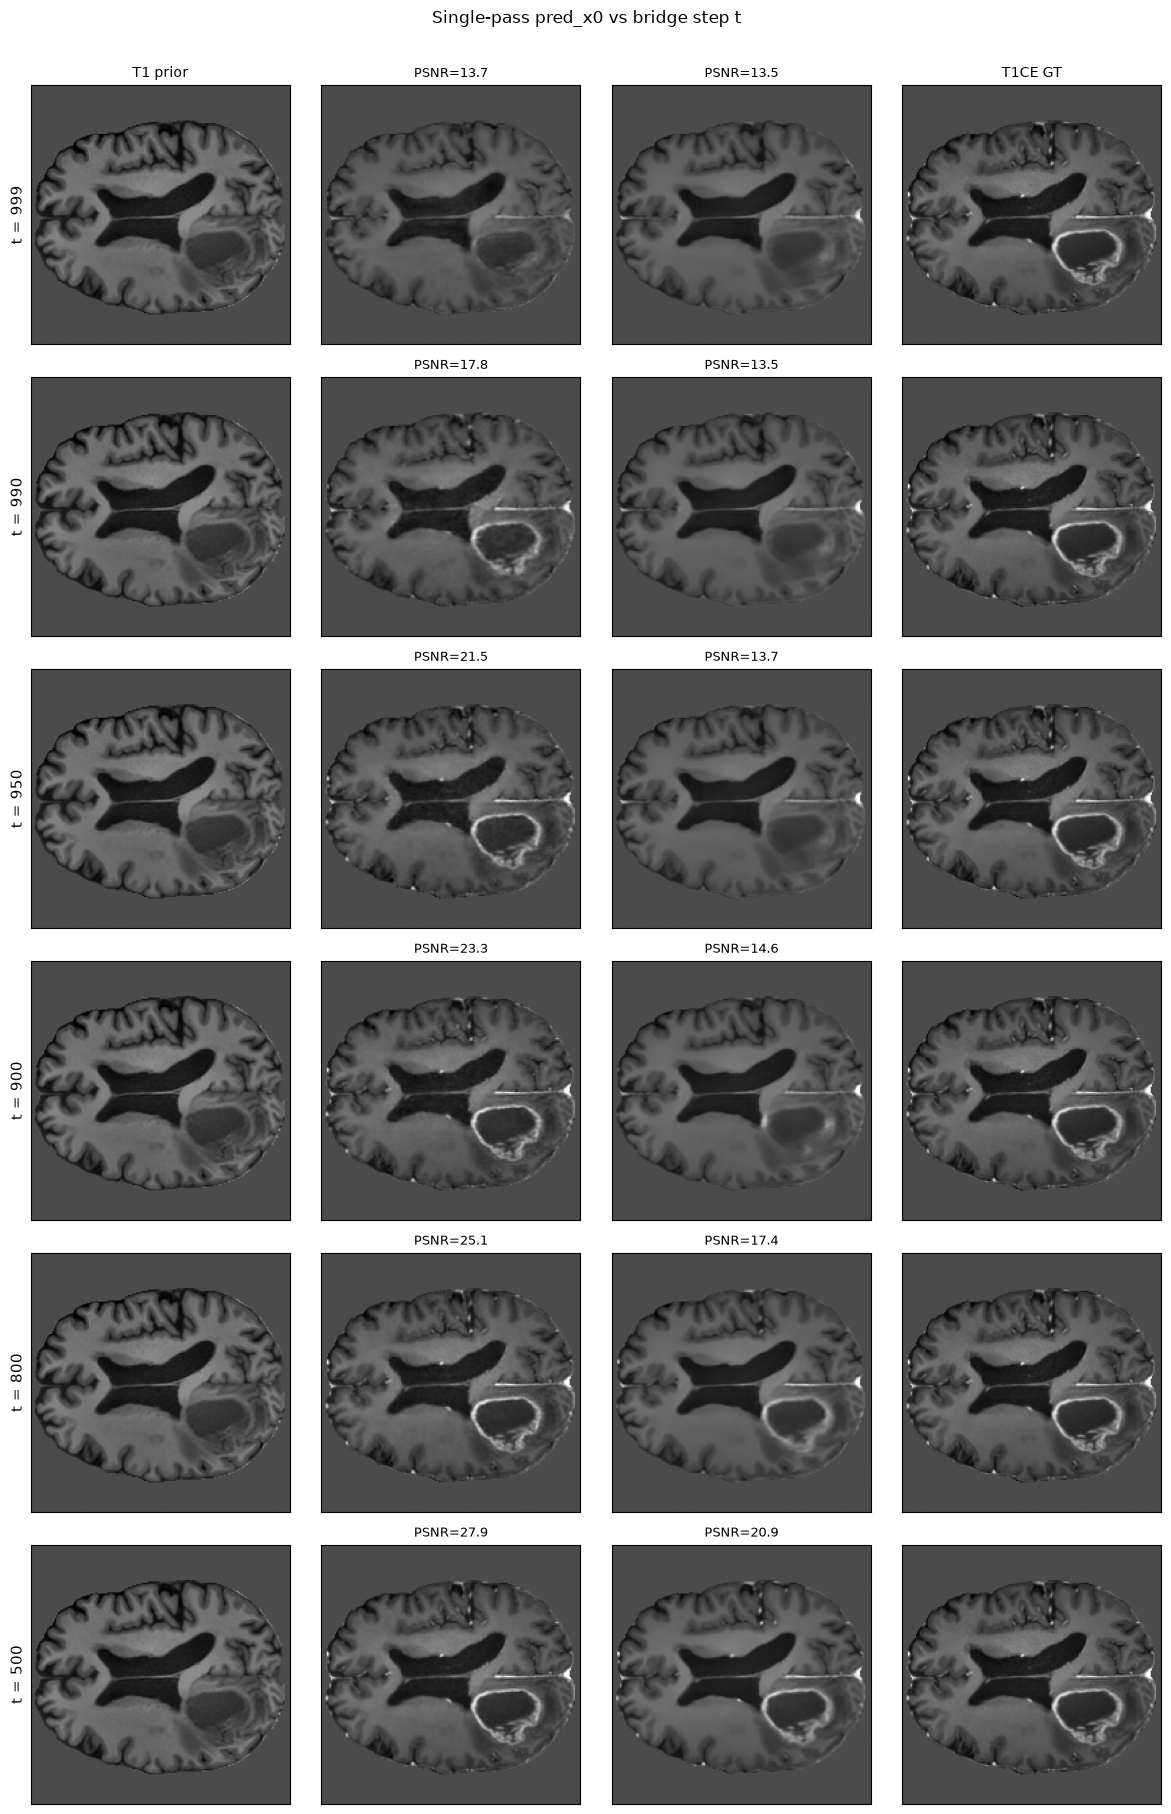

In [21]:
# grid: rows = t, cols = [T1 prior | latent-bridge | image-bridge | T1CE GT] for example 0
ok_names = [n for n, r in runs if r["ok"]]
ncol = 2 + len(ok_names)
lo, hi = disp_win(mask[:1] * x1[:1], mask[:1] * x0[:1])
fig, ax = plt.subplots(len(T_STEPS), ncol, figsize=(3 * ncol, 3 * len(T_STEPS))); ax = np.atleast_2d(ax)
for i, t in enumerate(T_STEPS):
    row = [("T1 prior", x1[0, 0])]
    for nm in ok_names:
        g, r = apply_loss_mask(x0[:1], preds[(nm, t)], mask[:1], use_mask=True)
        ps = float(compute_metrics(g, r, psnr_only=True)["psnr"])
        row.append((f"{nm} PSNR={ps:.1f}", (mask[0] * preds[(nm, t)][0])[0]))
    row.append(("T1CE GT", (mask[0] * x0[0])[0]))
    for a, (ttl, im) in zip(ax[i], row):
        a.imshow(npy(im), cmap="gray", vmin=lo, vmax=hi); a.set_xticks([]); a.set_yticks([])
        if i == 0: a.set_title(ttl.split(" PSNR")[0], fontsize=10)
    ax[i, 0].set_ylabel(f"t = {t}", fontsize=11)
    for j, nm in enumerate(ok_names):
        g, r = apply_loss_mask(x0[:1], preds[(nm, t)], mask[:1], use_mask=True)
        ax[i, 1 + j].set_title(f"PSNR={float(compute_metrics(g, r, psnr_only=True)['psnr']):.1f}", fontsize=9)
fig.suptitle("Single-pass pred_x0 vs bridge step t", y=1.005); plt.tight_layout(); plt.show()